# Project 2 — Part I (c): Can a deadly disease extinguish the population?

*For a highly deadly disease, can the population be extinguished?*

To model death we add a single transition to the SIR model — infected individuals can now **die**
($I\to D$) as well as recover. An infected leaves $I$ at rate $\gamma+\delta$ and, on leaving,
dies with probability $\delta/(\gamma+\delta)$ or recovers otherwise. This is the SIRD model
(`simulate_sird` in [`sir_model.py`](sir_model.py)), the minimal extension of the refined Binomial
scheme of Section 0.2 needed to answer the question.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from sir_model import simulate_sird

IMAGES = Path("..") / "Images"
IMAGES.mkdir(exist_ok=True)

N, beta, gamma, I0, T = 10_000, 0.3, 0.1, 5, 300
print(f"N={N}, beta={beta}, gamma={gamma}, I0={I0}; reproduction number R0 = beta/(gamma+delta)")

N=10000, beta=0.3, gamma=0.1, I0=5; reproduction number R0 = beta/(gamma+delta)


## A deadly disease in action

A single trajectory using Ebola-like parameters: $\delta=0.1$, equal to $\gamma$, so the
case fatality rate $\delta/(\gamma+\delta)=50\%$, matching the WHO-reported case fatality rate
for Ebola disease ("around 50%", historical range 25-90%) [WHO fact sheet]
(https://www.who.int/news-room/fact-sheets/detail/ebola-disease). This gives
$R_0=\beta/(\gamma+\delta)=1.5$: deaths accumulate during the epidemic, but the disease burns
out with a clear majority of the population still alive ($S+R$).

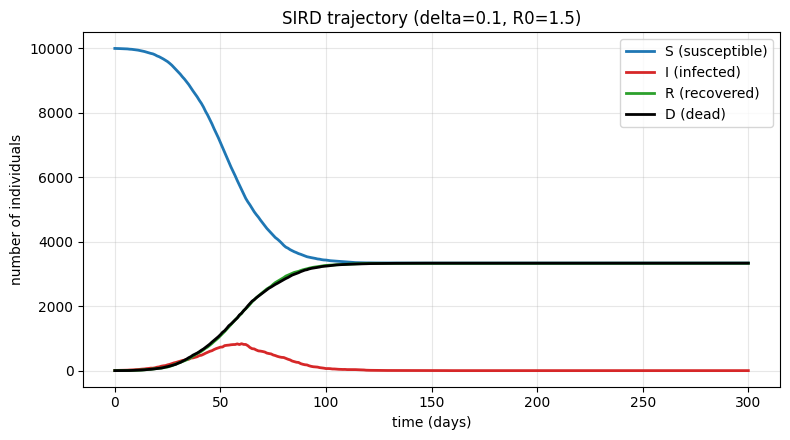

final: dead 3334 (33%), survivors 6666 (67%)


In [2]:
delta = 0.1                         # Ebola: CFR = delta/(gamma+delta) = 50% (WHO), R0 = beta/(gamma+delta) = 1.5
t, S, I, R, D = simulate_sird(N, beta, gamma, delta, I0, T, dt=1.0, rng=np.random.default_rng(2))

plt.figure(figsize=(8, 4.5))
plt.plot(t, S, color="tab:blue",  lw=2, label="S (susceptible)")
plt.plot(t, I, color="tab:red",   lw=2, label="I (infected)")
plt.plot(t, R, color="tab:green", lw=2, label="R (recovered)")
plt.plot(t, D, color="k",         lw=2, label="D (dead)")
plt.xlabel("time (days)"); plt.ylabel("number of individuals")
plt.title(f"SIRD trajectory (delta={delta}, R0={beta/(gamma+delta):.1f})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(IMAGES / "Proj2_PartC_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"final: dead {int(D[-1])} ({100*D[-1]/N:.0f}%), "
      f"survivors {int(S[-1]+R[-1])} ({100*(S[-1]+R[-1])/N:.0f}%)")

## Total mortality vs lethality

We sweep the death rate $\delta$ and record the share of the population that dies (mean over runs,
with a $5\!-\!95\%$ band). Increasing $\delta$ also shortens the infectious period, so it lowers the
reproduction number $R_0=\beta/(\gamma+\delta)$ — a more lethal disease spreads less.

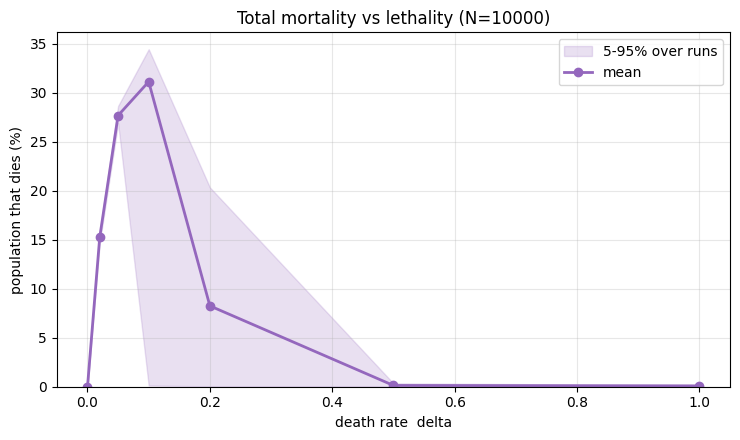

 delta |    R0 | mean dead % | mean alive %
   0.0 |  3.00 |         0.0 |        100.0
  0.02 |  2.50 |        15.3 |         84.7
  0.05 |  2.00 |        27.7 |         72.3
   0.1 |  1.50 |        31.1 |         68.9
   0.2 |  1.00 |         8.2 |         91.8
   0.5 |  0.50 |         0.1 |         99.9
   1.0 |  0.27 |         0.1 |         99.9


In [3]:
deltas = [0.0, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
reps = 60
mean_d, lo_d, hi_d = [], [], []
for delta in deltas:
    rng = np.random.default_rng(100)
    Dfin = np.array([simulate_sird(N, beta, gamma, delta, I0, T, 1.0, rng)[4][-1]
                     for _ in range(reps)])
    frac = 100 * Dfin / N
    mean_d.append(frac.mean()); lo_d.append(np.percentile(frac, 5)); hi_d.append(np.percentile(frac, 95))
mean_d = np.array(mean_d)

plt.figure(figsize=(7.5, 4.5))
plt.fill_between(deltas, lo_d, hi_d, alpha=0.2, color="tab:purple", label="5-95% over runs")
plt.plot(deltas, mean_d, "o-", color="tab:purple", lw=2, label="mean")
plt.xlabel("death rate  delta"); plt.ylabel("population that dies (%)")
plt.title(f"Total mortality vs lethality (N={N})")
plt.ylim(bottom=0); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(IMAGES / "Proj2_PartC_deaths_vs_delta.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'delta':>6} | {'R0':>5} | {'mean dead %':>11} | {'mean alive %':>12}")
for delta, md_ in zip(deltas, mean_d):
    print(f"{delta:>6} | {beta/(gamma+delta):>5.2f} | {md_:>11.1f} | {100-md_:>12.1f}")

## Conclusion

No — the population cannot be extinguished. Even the deadliest disease leaves a large majority
alive, because transmission stops once infected hosts die or recover: the disease removes its own
hosts. Total mortality is **non-monotonic** in lethality — it peaks at intermediate $\delta$ (about
a third of the population here) and collapses for very deadly diseases, which kill hosts before they
can transmit, dropping $R_0=\beta/(\gamma+\delta)$ below $1$. A more lethal disease is, paradoxically,
less deadly to the population as a whole.

---

**AI Declaration:** This notebook's code was refactored and commented with AI assistance. All results and conclusions were independently verified by a human supervisor.